In [ ]:
import numpy as np
import matplotlib.pyplot as plt

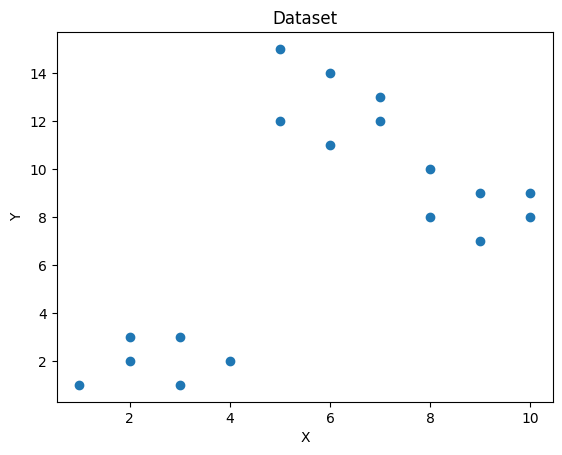

In [ ]:
data = np.array([
    [1,1],[2,2],[3,1],[4,2],[2,3],[3,3],
    [8,8],[9,7],[10,8],[9,9],[8,10],[10,9],
    [5,12],[6,11],[7,13],[6,14],[5,15],[7,12]
])

k = 3

plt.figure()
plt.scatter(data[:,0], data[:,1])
plt.title("Dataset")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [ ]:
def euclidean(a, b):
    return np.sqrt(np.sum((a - b)**2))

def manhattan(a, b):
    return np.sum(np.abs(a - b))

def squared_euclidean(a, b):
    return np.sum((a - b)**2)

def cosine_distance(a, b):
    dot = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    return 1 - (dot / (norm_a * norm_b))

In [ ]:
def kmeans_with_iteration_plot(data, k, distance_func, initial_centroids, method_name, max_iters=10):

    centroids = initial_centroids.copy()
    centroid_history = [centroids.copy()]

    print("\n==============================")
    print("Distance Measure:", method_name)
    print("Initial Centroids:\n", centroids)

    # ---- Iteration 0 ----
    plt.figure()
    plt.scatter(data[:,0], data[:,1])
    plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=300)
    plt.title(f'{method_name} - Iteration 0 (Initial)')
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

    for iteration in range(max_iters):

        clusters = [[] for _ in range(k)]

        for point in data:
            distances = [distance_func(point, c) for c in centroids]
            cluster_index = np.argmin(distances)
            clusters[cluster_index].append(point)

        old_centroids = centroids.copy()

        for i in range(k):
            if clusters[i]:
                centroids[i] = np.mean(clusters[i], axis=0)

        centroid_history.append(centroids.copy())

        print(f"\nIteration {iteration+1}")
        print("Updated Centroids:\n", centroids)

        plt.figure()

        for i in range(k):
            cluster = np.array(clusters[i])
            if len(cluster) > 0:
                plt.scatter(cluster[:,0], cluster[:,1], label=f'Cluster {i+1}')

        # centroid movement
        for i in range(len(centroid_history)-1):
            for j in range(k):
                x_vals = [centroid_history[i][j][0], centroid_history[i+1][j][0]]
                y_vals = [centroid_history[i][j][1], centroid_history[i+1][j][1]]
                plt.plot(x_vals, y_vals, linestyle='dashed')

        plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=300, label='Centroids')

        plt.title(f'{method_name} - Iteration {iteration+1}')
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.legend()
        plt.show()

        if np.allclose(old_centroids, centroids):
            print("Converged at iteration", iteration+1)
            break

    print("Total Iterations:", iteration+1)


Distance Measure: Euclidean
Initial Centroids:
 [[ 1.  1.]
 [10.  8.]
 [ 6. 14.]]


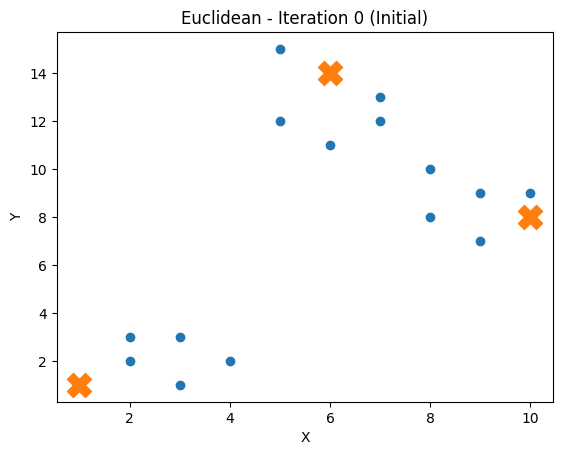


Iteration 1
Updated Centroids:
 [[ 2.5         2.        ]
 [ 9.          8.5       ]
 [ 6.         12.83333333]]


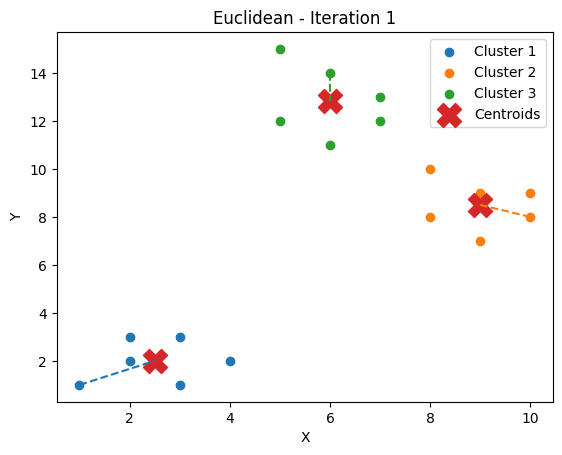


Iteration 2
Updated Centroids:
 [[ 2.5         2.        ]
 [ 9.          8.5       ]
 [ 6.         12.83333333]]


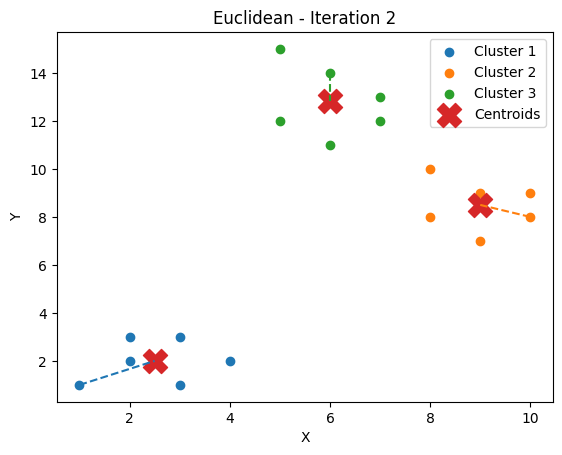

Converged at iteration 2
Total Iterations: 2


In [ ]:
initial_centroids = np.array([[1,1], [10,8], [6,14]], dtype=float)

kmeans_with_iteration_plot(
    data=data,
    k=3,
    distance_func=euclidean,
    initial_centroids=initial_centroids,
    method_name="Euclidean"
)


Distance Measure: Manhattan
Initial Centroids:
 [[ 2.  3.]
 [ 9.  9.]
 [ 5. 12.]]


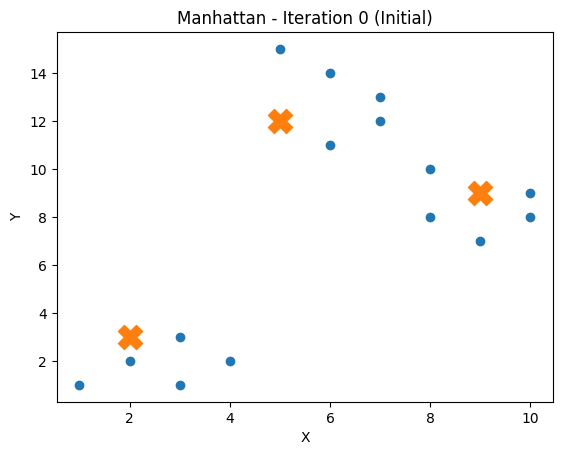


Iteration 1
Updated Centroids:
 [[ 2.5         2.        ]
 [ 9.          8.5       ]
 [ 6.         12.83333333]]


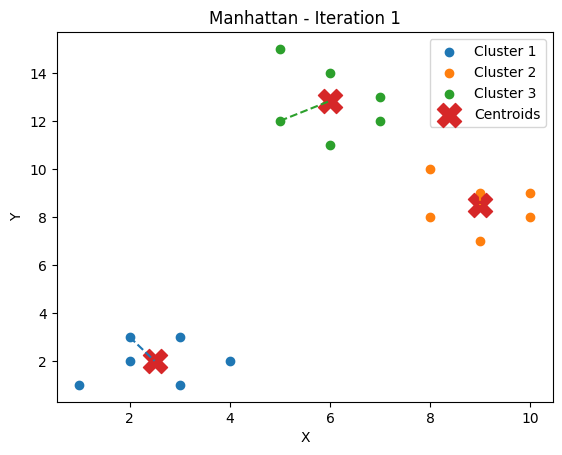


Iteration 2
Updated Centroids:
 [[ 2.5         2.        ]
 [ 9.          8.5       ]
 [ 6.         12.83333333]]


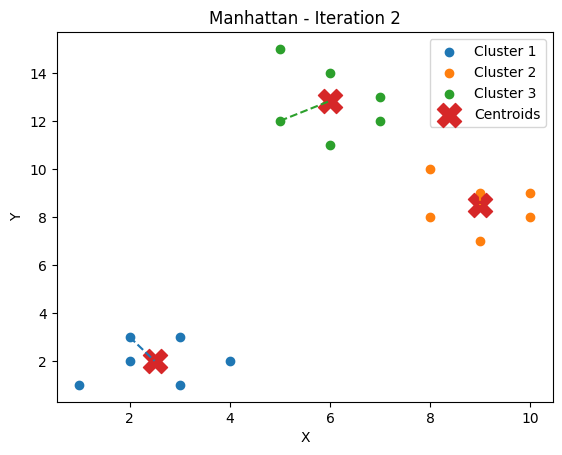

Converged at iteration 2
Total Iterations: 2


In [ ]:
initial_centroids = np.array([[2,3], [9,9], [5,12]], dtype=float)

kmeans_with_iteration_plot(
    data=data,
    k=3,
    distance_func=manhattan,
    initial_centroids=initial_centroids,
    method_name="Manhattan"
)


Distance Measure: Squared Euclidean
Initial Centroids:
 [[ 4.  2.]
 [ 8. 10.]
 [ 7. 13.]]


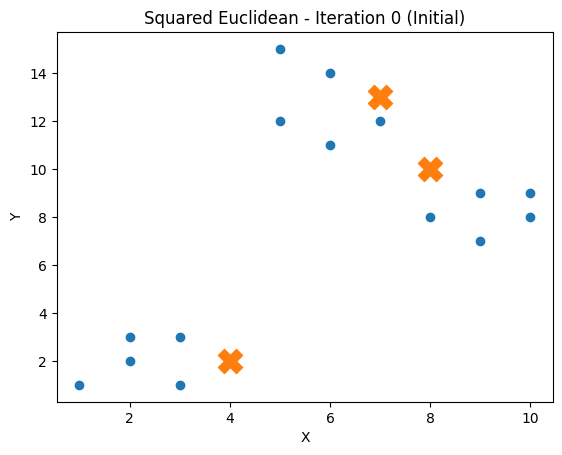


Iteration 1
Updated Centroids:
 [[ 2.5         2.        ]
 [ 8.57142857  8.85714286]
 [ 6.         13.2       ]]


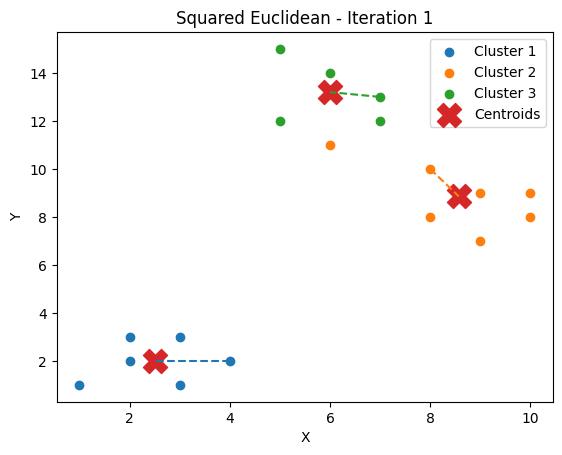


Iteration 2
Updated Centroids:
 [[ 2.5         2.        ]
 [ 9.          8.5       ]
 [ 6.         12.83333333]]


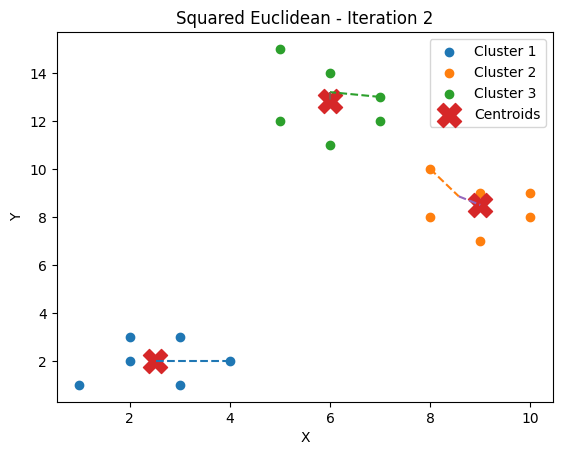


Iteration 3
Updated Centroids:
 [[ 2.5         2.        ]
 [ 9.          8.5       ]
 [ 6.         12.83333333]]


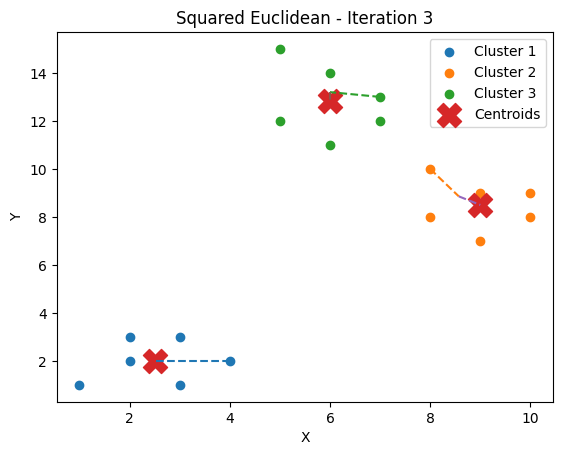

Converged at iteration 3
Total Iterations: 3


In [ ]:
initial_centroids = np.array([[4,2], [8,10], [7,13]], dtype=float)

kmeans_with_iteration_plot(
    data=data,
    k=3,
    distance_func=squared_euclidean,
    initial_centroids=initial_centroids,
    method_name="Squared Euclidean"
)


Distance Measure: Cosine
Initial Centroids:
 [[ 3.  1.]
 [10.  9.]
 [ 5. 15.]]


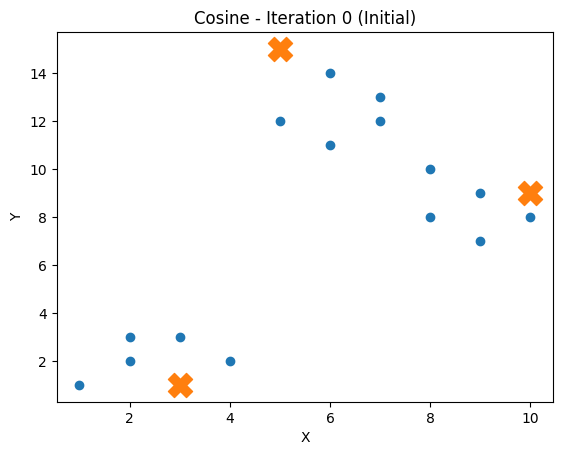


Iteration 1
Updated Centroids:
 [[ 3.5         1.5       ]
 [ 6.2         6.        ]
 [ 6.         12.83333333]]


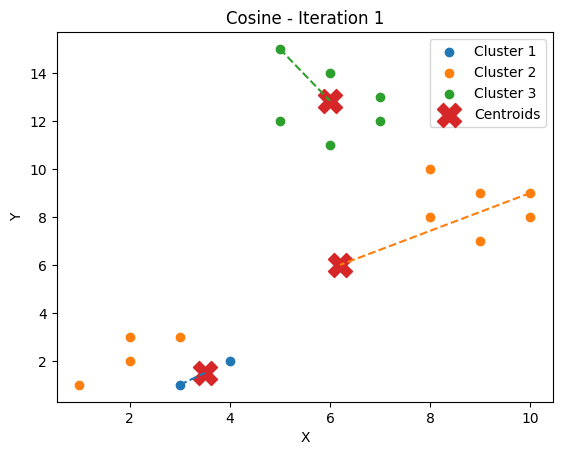


Iteration 2
Updated Centroids:
 [[ 3.5         1.5       ]
 [ 6.66666667  6.33333333]
 [ 5.42857143 11.42857143]]


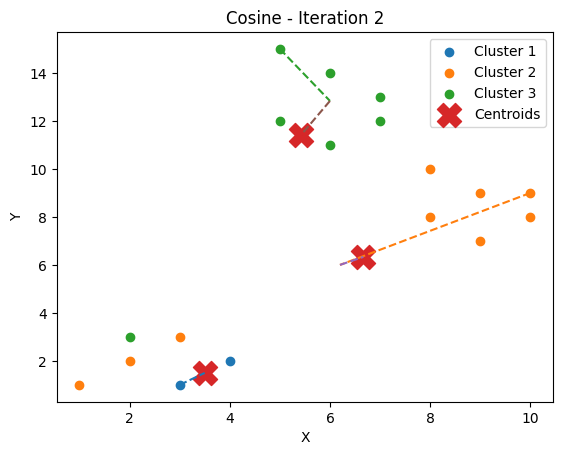


Iteration 3
Updated Centroids:
 [[ 3.5         1.5       ]
 [ 6.66666667  6.33333333]
 [ 5.42857143 11.42857143]]


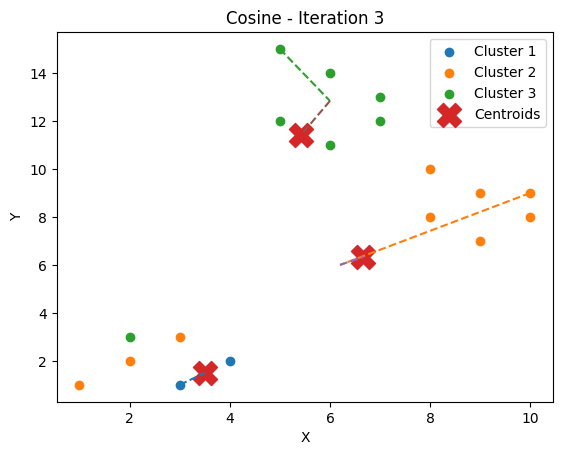

Converged at iteration 3
Total Iterations: 3


In [ ]:
initial_centroids = np.array([[3,1], [10,9], [5,15]], dtype=float)

kmeans_with_iteration_plot(
    data=data,
    k=3,
    distance_func=cosine_distance,
    initial_centroids=initial_centroids,
    method_name="Cosine"
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from PIL import Image

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Lenna_(test_image).png to Lenna_(test_image) (1).png


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

image = Image.open("Lenna_(test_image).png")  # replace with uploaded name

In [ ]:
image = image.resize((150, 150))

In [ ]:
image_np = np.array(image)
pixels = image_np.reshape(-1, 3)

In [ ]:
kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=1,
    max_iter=100
)

kmeans.fit(pixels)

KMeans(max_iter=100, n_init=1, random_state=42)

In [ ]:
compressed_pixels = kmeans.cluster_centers_[kmeans.labels_]
compressed_image = compressed_pixels.reshape(image_np.shape)

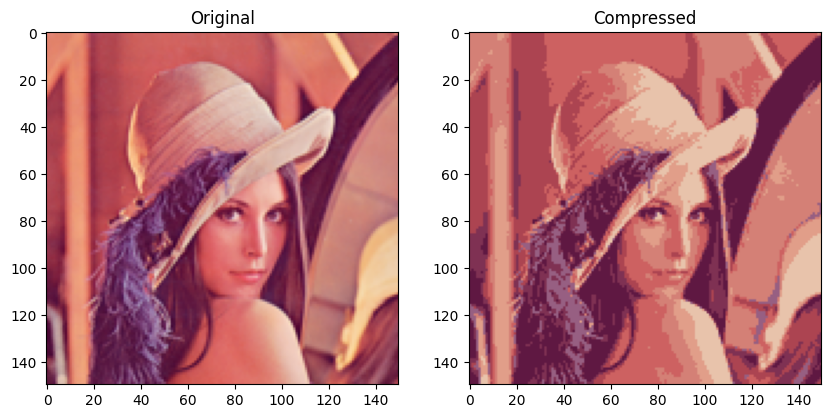

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_np)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(compressed_image.astype(np.uint8))
plt.title("Compressed")

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

sample_size = 2000

if len(pixels) > sample_size:
    idx = np.random.choice(len(pixels), sample_size, replace=False)
    pixels_sample = pixels[idx]
    labels_sample = kmeans.labels_[idx]
else:
    pixels_sample = pixels
    labels_sample = kmeans.labels_

sil_score = silhouette_score(pixels_sample, labels_sample)

print("Silhouette Coefficient:", sil_score)

Silhouette Coefficient: 0.4149031293514686


In [ ]:
sse = kmeans.inertia_
print("Sum of Squared Errors (SSE):", sse)

Sum of Squared Errors (SSE): 8259317.484262414


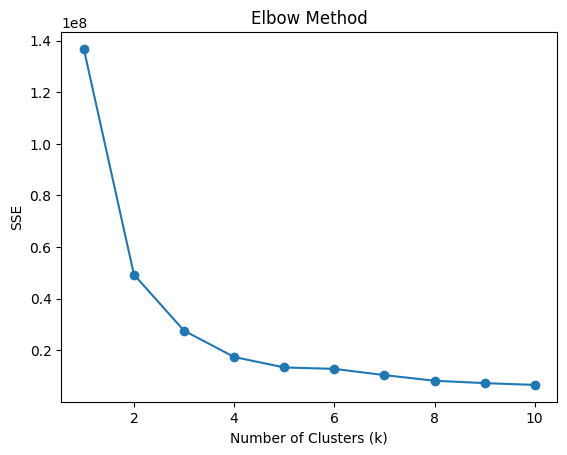

In [ ]:
sse_values = []

k_range = range(1, 11)

for k in k_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=1,
        max_iter=100
    )
    km.fit(pixels)
    sse_values.append(km.inertia_)

plt.figure()
plt.plot(k_range, sse_values, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans_random = KMeans(
    n_clusters=16,
    init='random',
    n_init=1,
    max_iter=100,
    random_state=42
)

kmeans_random.fit(pixels)

print("Random Init SSE:", kmeans_random.inertia_)

Random Init SSE: 4389317.355647469


In [ ]:
kmeans_plus = KMeans(
    n_clusters=16,
    init='k-means++',
    n_init=1,
    max_iter=100,
    random_state=42
)

kmeans_plus.fit(pixels)

print("KMeans++ SSE:", kmeans_plus.inertia_)

KMeans++ SSE: 4093436.1030617086


In [ ]:
import pandas as pd
import numpy as np

data = {
    "Player": ["Messi","Ronaldo","Neymar","Mbappe","Haaland",
               "Modric","De Bruyne","Kroos","Bellingham","Pedri",
               "Van Dijk","Ruben Dias","Alaba","Thiago Silva","Rudiger"],

    "Goals": [30,28,22,35,40,8,12,7,10,6,3,4,5,2,4],
    "Assists": [18,10,14,8,5,12,20,15,9,11,2,1,3,1,2],
    "PassAccuracy": [89,85,87,83,78,92,90,93,88,91,86,84,88,85,83],
    "Tackles": [5,4,6,3,2,20,18,15,17,16,30,28,25,27,29]
}

df = pd.DataFrame(data)
df

,Player,Goals,Assists,PassAccuracy,Tackles
0,Messi,30,18,89,5
1,Ronaldo,28,10,85,4
2,Neymar,22,14,87,6
3,Mbappe,35,8,83,3
4,Haaland,40,5,78,2
5,Modric,8,12,92,20
6,De Bruyne,12,20,90,18
7,Kroos,7,15,93,15
8,Bellingham,10,9,88,17
9,Pedri,6,11,91,16


In [ ]:
from sklearn.preprocessing import StandardScaler

features = df[["Goals","Assists","PassAccuracy","Tackles"]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
from sklearn.cluster import KMeans

kmeans_players = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans_players.fit_predict(scaled_features)

df

,Player,Goals,Assists,PassAccuracy,Tackles,Cluster
0,Messi,30,18,89,5,2
1,Ronaldo,28,10,85,4,2
2,Neymar,22,14,87,6,2
3,Mbappe,35,8,83,3,2
4,Haaland,40,5,78,2,1
5,Modric,8,12,92,20,0
6,De Bruyne,12,20,90,18,0
7,Kroos,7,15,93,15,0
8,Bellingham,10,9,88,17,0
9,Pedri,6,11,91,16,0


In [ ]:
for i in range(3):
    print(f"\nCluster {i} Players:")
    print(df[df["Cluster"] == i]["Player"].values)


Cluster 0 Players:
['Modric' 'De Bruyne' 'Kroos' 'Bellingham' 'Pedri' 'Van Dijk' 'Ruben Dias'
 'Alaba' 'Thiago Silva' 'Rudiger']

Cluster 1 Players:
['Haaland']

Cluster 2 Players:
['Messi' 'Ronaldo' 'Neymar' 'Mbappe']


In [ ]:
from sklearn.metrics import silhouette_score

sil_score_players = silhouette_score(scaled_features, df["Cluster"])
print("Silhouette Score:", sil_score_players)

Silhouette Score: 0.3323425803231341


In [ ]:
print("SSE:", kmeans_players.inertia_)

SSE: 25.749708751644196


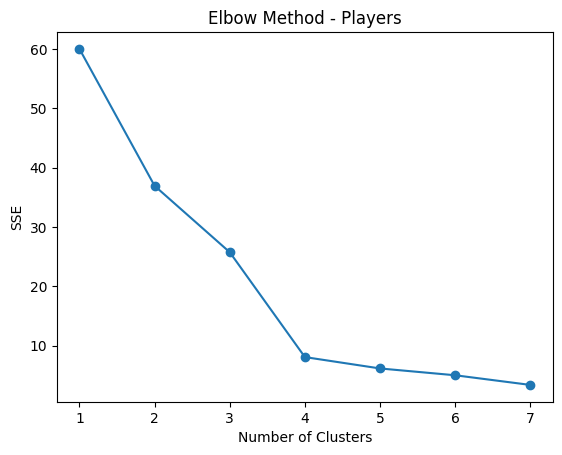

In [ ]:
sse = []

for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_features)
    sse.append(km.inertia_)

import matplotlib.pyplot as plt

plt.plot(range(1, 8), sse, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.title("Elbow Method - Players")
plt.show()